 # Data Exploration and Pre-processing

In [2]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings("ignore")

# 1) Load the given dataset

In [3]:
data = pd.read_csv("1768456122330-ML Project - Linear Regression Insurance Prediction 16955515670.txt")

In [4]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [6]:
data.duplicated().sum()

np.int64(1)

In [7]:
data = data.drop_duplicates()

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 83.6+ KB


In [9]:
print(data.shape)

(1337, 7)


In [10]:
data.describe(include="all")

,age,sex,bmi,children,smoker,region,charges
count,1337.000000,1337,1337.000000,1337.000000,1337,1337,1337.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,675,NaN,NaN,1063,364,NaN
mean,39.222139,NaN,30.663452,1.095737,NaN,NaN,13279.121487
std,14.044333,NaN,6.100468,1.205571,NaN,NaN,12110.359656
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.290000,0.000000,NaN,NaN,4746.344000
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9386.161300
75%,51.000000,NaN,34.700000,2.000000,NaN,NaN,16657.717450


# 2) Fill Null value of children column with the value 0

In [11]:
data["children"] = data["children"].fillna(0)

In [12]:
data["children"].isnull().sum()

np.int64(0)

# 3) Replace the Null values of the column BMI with mean value

In [13]:
data["bmi"] = data["bmi"].fillna(data["bmi"].mean())

In [14]:
data["bmi"].isnull().sum()

np.int64(0)

In [15]:
data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

# 4) Display a scatter plot between age and children

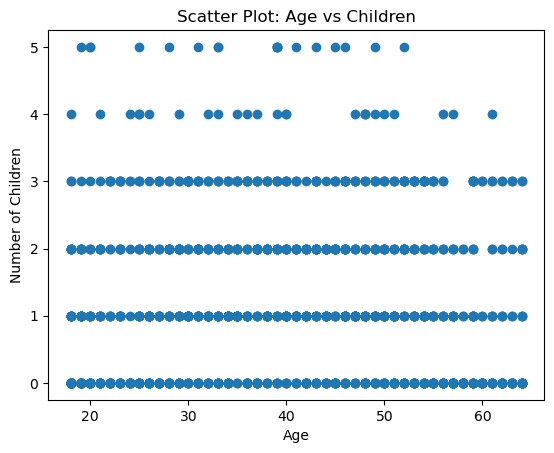

In [16]:
import matplotlib.pyplot as plt

plt.scatter(data["age"], data["children"])

plt.xlabel("Age")
plt.ylabel("Number of Children")
plt.title("Scatter Plot: Age vs Children")

plt.show()

# 5) Display bar plot between BMI and children

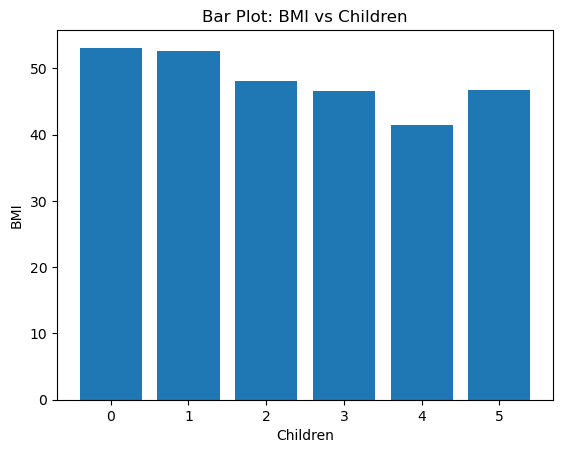

In [17]:
plt.bar(data['children'], data['bmi'])

plt.xlabel('Children')
plt.ylabel('BMI')
plt.title('Bar Plot: BMI vs Children')
plt.show()

array([[<Axes: title={'center': 'age'}>, <Axes: title={'center': 'bmi'}>],
       [<Axes: title={'center': 'children'}>,
        <Axes: title={'center': 'charges'}>]], dtype=object)

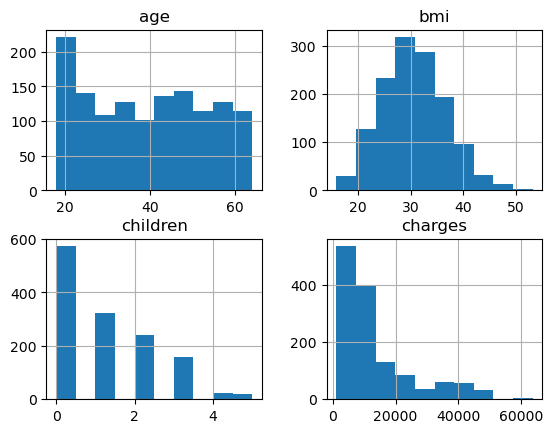

In [18]:
data.hist()

# 6) Perform encoding to convert character data into numerical data 

In [19]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [20]:
encoder = LabelEncoder()

In [21]:
data.select_dtypes(include='object').columns

Index(['sex', 'smoker', 'region'], dtype='object')

In [22]:
for col in data.select_dtypes(include='object').columns:
    data[col] = encoder.fit_transform(data[col].astype(str))

In [23]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


# 7) Perform scaling

In [24]:
scaler = StandardScaler()

data_scaled = pd.DataFrame(
    scaler.fit_transform(data),
    columns=data.columns
)

data_scaled.head()

,age,sex,bmi,children,smoker,region,charges
0,-1.440418,-1.009771,-0.453160,-0.909234,1.969660,1.343163,0.297857
1,-1.511647,0.990324,0.509422,-0.079442,-0.507702,0.438017,-0.954381
2,-0.799350,0.990324,0.383155,1.580143,-0.507702,0.438017,-0.729373
3,-0.443201,0.990324,-1.305052,-0.909234,-0.507702,-0.467128,0.719104
4,-0.514431,0.990324,-0.292456,-0.909234,-0.507702,-0.467128,-0.777499


# Working with Models

# 1. Separate features and target

In [25]:
x = data.drop('charges', axis=1)
y = data['charges']

# 2. Split data into training and testing

In [26]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.8, random_state=42)

In [27]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [28]:
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


# 3. Training and testing score

In [29]:
print("Training Score:", model.score(x_train, y_train)*100)
print("Testing Score:", model.score(x_test, y_test)*100)

Training Score: 72.97182858804965
Testing Score: 80.68466322629114


# 4. Intercept and slope

In [30]:
print("Intercept:", model.intercept_)
print("Slopes:", model.coef_)

Intercept: -11047.686556720208
Slopes: [  248.76407134   -99.69539417   312.60904469   534.12087654
 23052.15275173  -237.62514748]


In [31]:
# Display slope for each feature
for feature, coefficient in zip(x.columns, model.coef_):
    print(feature, ":", coefficient)

age : 248.76407133644207
sex : -99.69539416963103
bmi : 312.60904469262226
children : 534.1208765412467
smoker : 23052.152751729172
region : -237.62514748443053


In [32]:
# Predictions
y_pred = model.predict(x_test)

# 5. Mean Squared Error

In [33]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 35493102.6116505


# 6. Mean Absolute Error

In [34]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 4182.353155288295


# 7. Root Mean Squared Error

In [35]:
rmse = np.sqrt(mse)
print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 5957.608799816458


# 8. R2 Score

In [36]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)*100
print("R2 Score:", r2)

R2 Score: 80.68466322629114


# Random Forest

In [37]:
# Model evaluation (from sklearn.ensemble import RandomForestClassifier)

from sklearn.ensemble import RandomForestRegressor

model1 = RandomForestRegressor(random_state=42)

model1.fit(x_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [38]:
# Training and Testing accuracy

In [39]:
model1.score(x_train,y_train)

0.9735877745820769

In [40]:
model1.score(x_test,y_test)

0.8834278119122363

In [41]:
# Prediction and Testing metrics

In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [43]:
y_pred1 = model1.predict(x_test)

In [44]:
mae = mean_absolute_error(y_test, y_pred1)
mse = mean_squared_error(y_test, y_pred1)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred1)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 2555.9294270283576
Mean Squared Error (MSE): 21420846.45966618
Root Mean Squared Error (RMSE): 4628.2660316436195
R² Score: 0.8834278119122363
